## Extrenal Data with noise -pinn with no ICs

---
We train a PINN for the three-body problem using noisy observations from the periodic Figure-8 orbit, without providing any initial conditions. The motivation for this setup stems from observations in previous experiments: when trained on sparse, high-noise data without prescribed initial conditions, PINNs often converge to solutions whose inferred initial conditions correspond to different periodic orbits. This behavior suggests that the network may exploit the underlying dynamical structure of the system and motivates further investigation into its ability to recover or identify periodic solutions.

* A softening parameter, eps = 10⁻⁹, is introduced in the gravitational interaction terms to prevent numerical singularities when two bodies approach very small separations.

* The output-layer biases are initialized to nonzero values to avoid the network producing trivial zero-valued predictions at t = 0.

* A fixed random seed is supplied to the weight initializer
  (initializer = tf.keras.initializers.GlorotNormal(seed=seed))
  to ensure deterministic network initialization and improve the reproducibility of training results.

#Training Procedure
---
1. Train the PINN using sparse noisy observational data without providing initial conditions.

2. Extract the initial conditions inferred by the trained network.

3. Use the inferred initial conditions as an initial guess in a least-squares optimization procedure to identify a nearby periodic orbit.
**Important:** The least-squares refinement requires a reasonable initial estimate of the orbit period. Poor period estimates can cause the optimization to fail or converge to nonphysical solutions, including zero or negative periods.

4. Integrate the equations of motion numerically using the refined initial conditions and validate the resulting orbit.

***Observation***: By varying the random seed used for network initialization, the PINN may converge to different solutions. In some cases, the inferred initial conditions lead, after least-squares refinement, to periodic orbits that do not belong to the Figure-8 family. This suggests that the training process can explore multiple regions of the solution space and may provide a mechanism for identifying distinct periodic three-body trajectories.



In [ ]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde

In [ ]:
!pip install tensorflow tf_keras matplotlib numpy scipy

## IMPORTS

In [ ]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

# Training

Set the default float type to float64
Init_net_seed ===>  15
Global_seed ===>  137
noise_seed ===>  137
Compiling model...
'compile' took 0.000307 s



Model: "fnn_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (1, 64)                │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (1, 6)                 │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,838 (69.05 KB)

 Trainable params: 8,838 (69.05 KB)

 Non-trainable params: 0 (0.00 B)

old bias: [0. 0. 0. 0. 0. 0.]
new bias: [-0.2  0.2  0.   0.   0.2 -0.2]


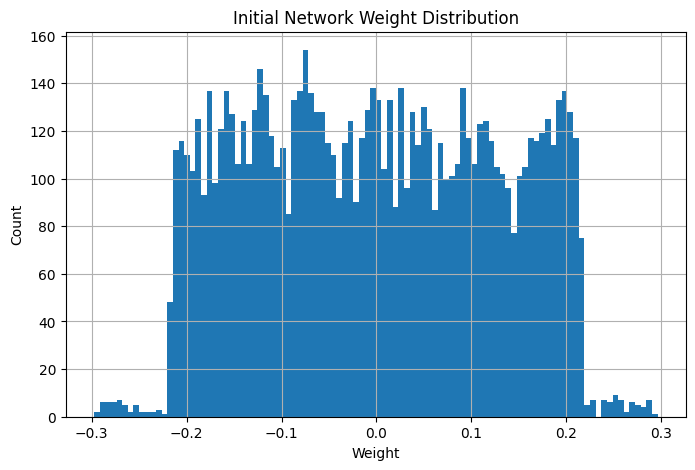

sum = -9.998398788254438
norm = 11.893689992724227
Training model...

Step      Train loss                                                                                                                  Test loss                                                                                                                   Test metric
0         [2.51e+02, 5.82e+01, 9.10e+01, 5.58e+01, 5.66e+01, 3.60e+01, 4.88e-02, 3.38e-02, 1.97e-01, 1.13e-02, 3.62e-02, 4.68e-01]    [2.86e+02, 5.52e+01, 1.09e+02, 6.42e+01, 5.31e+01, 2.98e+01, 4.88e-02, 3.38e-02, 1.97e-01, 1.13e-02, 3.62e-02, 4.68e-01]    []  
1000      [2.79e-01, 1.95e-02, 1.51e-01, 1.66e-01, 4.69e-02, 2.83e-01, 6.07e-01, 9.87e-02, 4.78e-01, 5.57e-01, 2.74e-02, 4.69e-01]    [2.99e-01, 2.10e-02, 1.58e-01, 1.78e-01, 5.06e-02, 3.07e-01, 6.07e-01, 9.87e-02, 4.78e-01, 5.57e-01, 2.74e-02, 4.69e-01]    []  
2000      [5.47e-02, 1.04e-02, 6.87e-02, 1.14e-02, 1.30e-02, 1.63e-02, 3.02e-01, 2.23e-02, 3.73e-01, 8.47e-02, 7.87e-03, 1.39e-01]    

In [ ]:


# https://numericaltank.sjtu.edu.cn/three-body/three-body-movies.htm   first member of orbits
dde.config.set_default_float("float64")

seed=15                #7

Init_net_seed=seed    #change to get different network initializations


Global_seed=137  #keep fixed to have same collocation points for pde residues

noise_seed=137  # keep fixed to have same noisy data in every test

print("Init_net_seed ===> ",Init_net_seed)
print("Global_seed ===> ",Global_seed)
print("noise_seed ===> ",noise_seed)
dde.config.set_random_seed(Global_seed)
np.random.seed(Global_seed)
tf.random.set_seed(Global_seed)

# ============================================================
# Constants
# ============================================================
scale =4**(1/3)
G = 1.0
m = [1.0, 1.0, 1.0]

endTime = 4 / scale**3


num_domain = 64
num_boundary = 12
num_test = 100


layer_size = [1] + [64]*3 + [6]
activation = "sin"
initializer =tf.keras.initializers.GlorotUniform(seed=Init_net_seed)
#initializer ="Glorot normal" #"Glorot uniform" "Glorot normal"# "He normal" #

iterations =25000
learning_rate = 1e-3
wr=1     #Lpde weight
wd=1    #data weight
loss_weights=[wr]*6+[wd]*6
optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001,weight_decay=0)  #0.004


eps = 1e-9

# ============================================================
# Initial Conditions for Lagrange orbit
# ============================================================
omega = 0.3

x1_0, y1_0 = -1.0/scale**2, 0.0/scale**2
x2_0, y2_0 =  1.0/scale**2, 0.0/scale**2
x3_0, y3_0 =  0.0/scale**2, np.sqrt(3)/scale**2

vx1_0, vy1_0 = (-np.sqrt(3)/3)*omega*scale, 1*omega*scale
vx2_0, vy2_0 = (-np.sqrt(3)/3)*omega*scale, -1*omega*scale
vx3_0, vy3_0 = (2*np.sqrt(3)/3)*omega*scale, 0

y0 = np.array([x1_0,y1_0,x2_0,y2_0,x3_0,y3_0])
v0 = np.array([vx1_0,vy1_0,vx2_0,vy2_0,vx3_0,vy3_0])

y0_tf = tf.constant(y0)
v0_tf = tf.constant(v0)


# ============================================================
# NUMERICAL SOLUTION (for synthetic measurements)
# ============================================================

def three_body_numeric(t, y):

    x1,y1,vx1,vy1,x2,y2,vx2,vy2,x3,y3,vx3,vy3 = y

    r12 = np.sqrt((x1-x2)**2 + (y1-y2)**2 + eps)
    r13 = np.sqrt((x1-x3)**2 + (y1-y3)**2 + eps)
    r23 = np.sqrt((x2-x3)**2 + (y2-y3)**2 + eps)

    ax1 = G*(m[1]*(x2-x1)/r12**3 + m[2]*(x3-x1)/r13**3)
    ay1 = G*(m[1]*(y2-y1)/r12**3 + m[2]*(y3-y1)/r13**3)

    ax2 = G*(m[0]*(x1-x2)/r12**3 + m[2]*(x3-x2)/r23**3)
    ay2 = G*(m[0]*(y1-y2)/r12**3 + m[2]*(y3-y2)/r23**3)

    ax3 = G*(m[0]*(x1-x3)/r13**3 + m[1]*(x2-x3)/r23**3)
    ay3 = G*(m[0]*(y1-y3)/r13**3 + m[1]*(y2-y3)/r23**3)

    return [vx1,vy1,ax1,ay1,
            vx2,vy2,ax2,ay2,
            vx3,vy3,ax3,ay3]


t_span = (0,endTime)
t_eval = np.linspace(0,endTime,5000)

y0_full = [
x1_0,y1_0,vx1_0,vy1_0,
x2_0,y2_0,vx2_0,vy2_0,
x3_0,y3_0,vx3_0,vy3_0
]

sol = solve_ivp(three_body_numeric,t_span,y0_full,
                t_eval=t_eval,rtol=1e-10,atol=1e-12)

x1_n,y1_n = sol.y[0],sol.y[1]
x2_n,y2_n = sol.y[4],sol.y[5]
x3_n,y3_n = sol.y[8],sol.y[9]

# ============================================================
# SYNTHETIC NOISY MEASUREMENTS
# ============================================================

num_obs = 30
noise_level = 0.2

# Independent RNG for noisy data
rng_noise = np.random.default_rng(noise_seed)

idx = np.sort(rng_noise.choice(len(t_eval),num_obs,replace=False))

t_obs = t_eval[idx][:,None]

y_obs_true = np.vstack([
x1_n[idx],y1_n[idx],
x2_n[idx],y2_n[idx],
x3_n[idx],y3_n[idx]
]).T

noise = noise_level*np.std(y_obs_true,axis=0)*rng_noise.standard_normal(y_obs_true.shape)

y_obs = y_obs_true + noise

# ============================================================
# PINN PDE
# ============================================================

def three_body_ode_second(t,y):

    x1,y1,x2,y2,x3,y3 = [y[:,i:i+1] for i in range(6)]

    r12 = tf.sqrt((x1-x2)**2 + (y1-y2)**2 +eps)
    r13 = tf.sqrt((x1-x3)**2 + (y1-y3)**2 +eps)
    r23 = tf.sqrt((x2-x3)**2 + (y2-y3)**2 +eps)

    ax1 = G*(m[1]*(x2-x1)/r12**3 + m[2]*(x3-x1)/r13**3)
    ay1 = G*(m[1]*(y2-y1)/r12**3 + m[2]*(y3-y1)/r13**3)

    ax2 = G*(m[0]*(x1-x2)/r12**3 + m[2]*(x3-x2)/r23**3)
    ay2 = G*(m[0]*(y1-y2)/r12**3 + m[2]*(y3-y2)/r23**3)

    ax3 = G*(m[0]*(x1-x3)/r13**3 + m[1]*(x2-x3)/r23**3)
    ay3 = G*(m[0]*(y1-y3)/r13**3 + m[1]*(y2-y3)/r23**3)

    x1_tt = dde.grad.hessian(y,t,component=0,i=0,j=0)
    y1_tt = dde.grad.hessian(y,t,component=1,i=0,j=0)
    x2_tt = dde.grad.hessian(y,t,component=2,i=0,j=0)
    y2_tt = dde.grad.hessian(y,t,component=3,i=0,j=0)
    x3_tt = dde.grad.hessian(y,t,component=4,i=0,j=0)
    y3_tt = dde.grad.hessian(y,t,component=5,i=0,j=0)

    return [
    (x1_tt-ax1),
    (y1_tt-ay1),
    (x2_tt-ax2),
    (y2_tt-ay2),
    (x3_tt-ax3),
    (y3_tt-ay3)
    ]

# ============================================================
# Geometry
# ============================================================

geom = dde.geometry.TimeDomain(0,endTime)

# observation constraints
observe_x1 = dde.PointSetBC(t_obs,y_obs[:,0:1],component=0)
observe_y1 = dde.PointSetBC(t_obs,y_obs[:,1:2],component=1)
observe_x2 = dde.PointSetBC(t_obs,y_obs[:,2:3],component=2)
observe_y2 = dde.PointSetBC(t_obs,y_obs[:,3:4],component=3)
observe_x3 = dde.PointSetBC(t_obs,y_obs[:,4:5],component=4)
observe_y3 = dde.PointSetBC(t_obs,y_obs[:,5:6],component=5)

data = dde.data.PDE(
geom,
three_body_ode_second,
[ observe_x1,observe_y1,observe_x2,observe_y2,observe_x3,observe_y3],
num_domain=num_domain,
num_boundary=num_boundary,
num_test=num_test
)

# ============================================================
# NETWORK
# ============================================================

net = dde.nn.FNN(layer_size,activation,initializer)


model = dde.Model(data,net)

model.compile(optimizer=optimizer,loss_weights=loss_weights)
#model.compile("adam",lr=learning_rate,loss_weights=loss_weights)

###############################################################
# Change bias in last layer to avoid zero outputs at t=0
###############################################################
model.predict([[0.0]])   #dummy predict to create model.. tensorflow behaviour
# modify bias
last_layer=3    #dependes on the number of layers layer 0 ,1,2,3 ....
model.net.summary()
last_layer = model.net.layers[last_layer]   # dense_3
w, b = last_layer.get_weights()
print("old bias:", b)
b = np.array([-0.2, 0.2, 0, 0, 0.2, -0.2])   # example separation
last_layer.set_weights([w, b])
print("new bias:", b)
##############################################################
##############################################################


# Output initial weight destribution

# Build network
model.predict([[0.0]])

# INITIAL WEIGHTS HISTOGRAM
all_weights = []

for layer in model.net.layers:

    w,b = layer.get_weights()

    all_weights.append(w.flatten())

all_weights = np.concatenate(all_weights)

plt.figure(figsize=(8,5))
plt.hist(all_weights,bins=100)
plt.title("Initial Network Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Count")
plt.grid(True)
plt.show()

#weights check
w_all = []

for layer in model.net.layers:
    w, b = layer.get_weights()
    w_all.append(w.flatten())

w_all = np.concatenate(w_all)

print("sum =", np.sum(w_all))
print("norm =", np.linalg.norm(w_all))

losshistory,train_state = model.train(iterations=iterations)

#model.compile("L-BFGS")
#losshistory,train_state = model.train()




# Plot training and test losses together with the PINN-predicted orbits

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


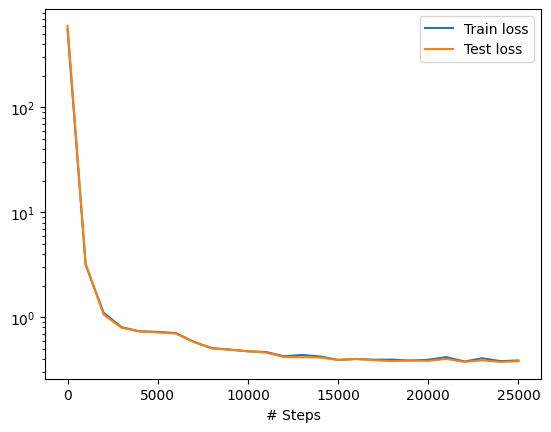

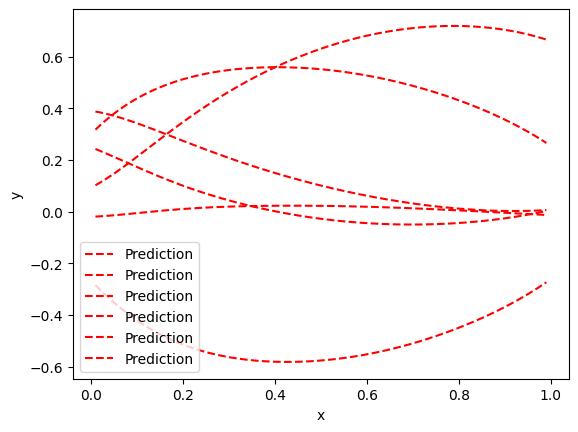

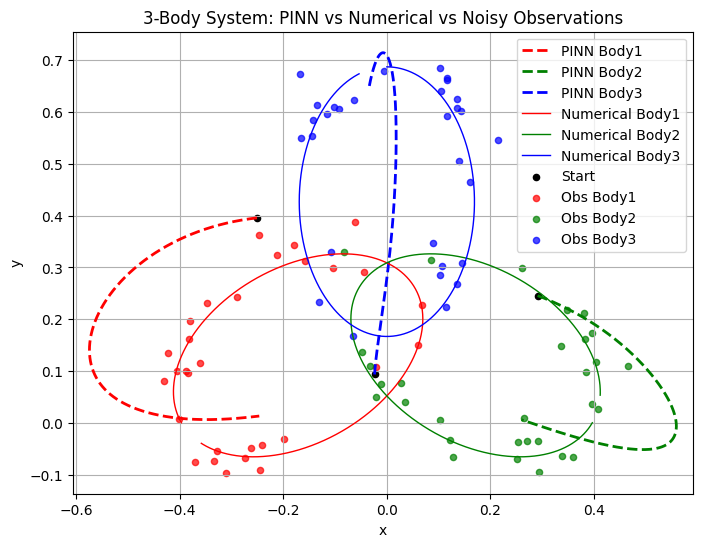

In [ ]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# ============================================================
# PINN PREDICTION
# ============================================================

t_test = np.linspace(0,endTime,5000)[:,None]

y_pred = model.predict(t_test)

x1,y1 = y_pred[:,0],y_pred[:,1]
x2,y2 = y_pred[:,2],y_pred[:,3]
x3,y3 = y_pred[:,4],y_pred[:,5]

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(x1,y1,'r--',lw=2,label="PINN Body1")
plt.plot(x2,y2,'g--',lw=2,label="PINN Body2")
plt.plot(x3,y3,'b--',lw=2,label="PINN Body3")

plt.plot(x1_n,y1_n,'r-',lw=1,label="Numerical Body1")
plt.plot(x2_n,y2_n,'g-',lw=1,label="Numerical Body2")
plt.plot(x3_n,y3_n,'b-',lw=1,label="Numerical Body3")

#starting points
plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=20, label='Start')

# noisy measurements
plt.scatter(y_obs[:,0],y_obs[:,1],c='red',s=20,alpha=0.7,label="Obs Body1")
plt.scatter(y_obs[:,2],y_obs[:,3],c='green',s=20,alpha=0.7,label="Obs Body2")
plt.scatter(y_obs[:,4],y_obs[:,5],c='blue',s=20,alpha=0.7,label="Obs Body3")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.title("3-Body System: PINN vs Numerical vs Noisy Observations")

plt.show()

#STATISTICS

In [ ]:
# ============================================================
# STATISTICS
# ============================================================


print("\n")
print("="*60)
print("STATISTICS")
print("="*60)

# ============================================================
# PINN velocities from automatic differentiation
# ============================================================

t_tf = tf.convert_to_tensor(t_test, dtype=tf.float64)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred_tf = model.net(t_tf)

dy_dt = tape.batch_jacobian(y_pred_tf, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:, :, 0].numpy()

# PINN positions
y_pred = y_pred_tf.numpy()

x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# PINN velocities
vx1, vy1 = dy_dt[:,0], dy_dt[:,1]
vx2, vy2 = dy_dt[:,2], dy_dt[:,3]
vx3, vy3 = dy_dt[:,4], dy_dt[:,5]

# ============================================================
# Numerical solution
# ============================================================

x1_n  = sol.y[0]
y1_n  = sol.y[1]
vx1_n = sol.y[2]
vy1_n = sol.y[3]

x2_n  = sol.y[4]
y2_n  = sol.y[5]
vx2_n = sol.y[6]
vy2_n = sol.y[7]

x3_n  = sol.y[8]
y3_n  = sol.y[9]
vx3_n = sol.y[10]
vy3_n = sol.y[11]

# ============================================================
# TRAIN / TEST LOSS
# ============================================================

train_losses = np.array(losshistory.loss_train)
test_losses  = np.array(losshistory.loss_test)

final_train_loss = np.sum(train_losses[-1])
final_test_loss  = np.sum(test_losses[-1])

# six PDE residuals
LPDE = np.sum(train_losses[-1][:6])

# six observation losses
LDATA = np.sum(train_losses[-1][6:])

print(f"Final Training Loss : {final_train_loss:.2e}")
print(f"Final Test Loss     : {final_test_loss:.2e}")
print(f"PDE Residual Loss   : {LPDE:.2e}")
print(f"Data Loss           : {LDATA:.2e}")

# ============================================================
# 2. POSITION ERRORS - RMSE
# ============================================================

err1 = np.sqrt((x1 - x1_n)**2 + (y1 - y1_n)**2)
err2 = np.sqrt((x2 - x2_n)**2 + (y2 - y2_n)**2)
err3 = np.sqrt((x3 - x3_n)**2 + (y3 - y3_n)**2)

rmse1 = np.sqrt(np.mean(err1**2))
rmse2 = np.sqrt(np.mean(err2**2))
rmse3 = np.sqrt(np.mean(err3**2))

RMSE = np.sqrt(np.mean(
    np.concatenate([
        err1**2,
        err2**2,
        err3**2
    ])
))

print("\nPosition RMSE")
print("-----------------------------")
print(f"Body 1 : {rmse1:.2e}")
print(f"Body 2 : {rmse2:.2e}")
print(f"Body 3 : {rmse3:.2e}")
print(f"Global : {RMSE:.2e}")

print("\nMaximum Position Error")
print("-----------------------------")
print(f"Body 1 : {np.max(err1):.2e}")
print(f"Body 2 : {np.max(err2):.2e}")
print(f"Body 3 : {np.max(err3):.2e}")

max_pos_error = max(
    np.max(err1),
    np.max(err2),
    np.max(err3)
)
print(f"Global Max Position error : {max_pos_error:.2e}")

# ============================================================
# 3. ENERGY
# ============================================================



def total_energy(x1,y1,vx1,vy1,
                 x2,y2,vx2,vy2,
                 x3,y3,vx3,vy3,
                 G=1.0,
                 m=(1.0,1.0,1.0),
                 eps=0.0):

    KE = (
        0.5*m[0]*(vx1**2+vy1**2)
        +0.5*m[1]*(vx2**2+vy2**2)
        +0.5*m[2]*(vx3**2+vy3**2)
    )

    r12 = np.sqrt((x1-x2)**2+(y1-y2)**2+eps)
    r13 = np.sqrt((x1-x3)**2+(y1-y3)**2+eps)
    r23 = np.sqrt((x2-x3)**2+(y2-y3)**2+eps)

    PE = (
        -G*m[0]*m[1]/r12
        -G*m[0]*m[2]/r13
        -G*m[1]*m[2]/r23
    )

    return KE + PE


E = total_energy(
    x1,y1,vx1,vy1,
    x2,y2,vx2,vy2,
    x3,y3,vx3,vy3,
    G,m,eps
)

E0 = E[0]

DE_E0 = np.max(np.abs(E-E0))/abs(E0)

print("\nEnergy Conservation")
print("-----------------------------")
print(f"PINN ΔE/E0 : {DE_E0:.2e}")

E_num = total_energy(
    x1_n, y1_n, vx1_n, vy1_n,
    x2_n, y2_n, vx2_n, vy2_n,
    x3_n, y3_n, vx3_n, vy3_n,
    G, m, eps
)

E0_num = E_num[0]

DE_E0_num = np.max(np.abs(E_num-E0_num))/abs(E0_num)


print("-----------------------------")
print(f"Numerical ΔE/E0 : {DE_E0_num:.2e}")

# ============================================================
# 4. LINEAR MOMENTUM DRIFT
# ============================================================

Px = m[0]*vx1 + m[1]*vx2 + m[2]*vx3
Py = m[0]*vy1 + m[1]*vy2 + m[2]*vy3

DeltaP = np.max(
    np.sqrt(
        (Px - Px[0])**2 +
        (Py - Py[0])**2
    )
)

print("\nLinear Momentum")
print("-----------------------------")
print(f"PINN Max Momentum Drift : {DeltaP:.2e}")

Px_n = m[0]*vx1_n + m[1]*vx2_n + m[2]*vx3_n
Py_n = m[0]*vy1_n + m[1]*vy2_n + m[2]*vy3_n

DeltaP_n = np.max(
    np.sqrt(
        (Px_n - Px_n[0])**2 +
        (Py_n - Py_n[0])**2
    )
)


print("-----------------------------")
print(f"Numerical Max Momentum Drift : {DeltaP_n:.2e}")


# ============================================================
# 5. ANGULAR MOMENTUM
# ============================================================

L = (
      m[0]*(x1*vy1-y1*vx1)
    + m[1]*(x2*vy2-y2*vx2)
    + m[2]*(x3*vy3-y3*vx3)
)

L0 = L[0]

DL_L0 = np.max(np.abs(L-L0))/max(abs(L0),1e-15)

print("\nAngular Momentum Conservation")
print("-----------------------------")
print(f"ΔL/L0 : {DL_L0:.2e}")

# ============================================================
# ORBIT DISCOVERY METRICS
# ============================================================

print("\n")
print("="*60)
print("ORBIT DISCOVERY METRICS")
print("="*60)

# ============================================================
# Initial inter-body distances (PINN inferred at t = 0)
# ============================================================

d12 = np.sqrt((x1[0]-x2[0])**2 + (y1[0]-y2[0])**2)
d13 = np.sqrt((x1[0]-x3[0])**2 + (y1[0]-y3[0])**2)
d23 = np.sqrt((x2[0]-x3[0])**2 + (y2[0]-y3[0])**2)

print("\nInitial Inter-body Distances")
print("-----------------------------")
print(f"d12 : {d12:.6e}")
print(f"d13 : {d13:.6e}")
print(f"d23 : {d23:.6e}")

# ============================================================
# Collinearity measure
# (permutation invariant)
# ============================================================

dist = np.sort([d12, d13, d23])

d_min = dist[0]
d_mid = dist[1]
d_max = dist[2]

collinearity = abs(d_max - (d_mid + d_min))

print("\nCollinearity Measure")
print("-----------------------------")
print(f"|d_max - (d_mid + d_min)| : {collinearity:.6e}")


# ============================================================
# Equilateral measure
# ============================================================

d_mean = (d12 + d13 + d23)/3

equilateral = max(
    abs(d12-d_mean),
    abs(d13-d_mean),
    abs(d23-d_mean)
) / d_mean

print("\nEquilateral Measure")
print("-----------------------------")
print(f"max|dij-d̄|/d̄ : {equilateral:.6e}")

# ============================================================
# Orbit classification
# ============================================================

euler_tol = 0.10
lagrange_tol = 0.15

if collinearity < euler_tol:
    orbit = "Euler"

elif equilateral < lagrange_tol:
    orbit = "Lagrange"

else:
    orbit = "Other"

print("\nDetected Orbit")
print("-----------------------------")
print(f"{orbit}")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*60)
print("SUMMARY")
print("="*60)

print("\nInitial Inter-body Distances")
print("-----------------------------")
print(f"d12 : {d12:.6e}")
print(f"d13 : {d13:.6e}")
print(f"d23 : {d23:.6e}")
print("-"*60)

print("\nInitial Orbit Discovery Metrics")
print("-----------------------------")
print(f"Detected Orbit                   : {orbit}")
print(f"Collinearity Measure             : {collinearity:.2e}")
print(f"Equilateral Measure              : {equilateral:.2e}")
print("-"*60)

print(f"Final Training Loss               : {final_train_loss:.2e}")
print(f"Final Test Loss                   : {final_test_loss:.2e}")
print(f"Final RAW training Loss           : {LPDE/wr + LDATA/wd:.2e}")
print(f"PDE Residual Loss                 : {LPDE:.2e}")
print(f"Data Loss                         : {LDATA:.2e}")
print(f"Global Max Position error         : {max_pos_error:.2e}")
print(f"Position RMSE                     : {RMSE:.2e}")
print(f"PINN ΔE/E0                        : {DE_E0:.2e}")
print(f"Numerical ΔE/E0                   : {DE_E0_num:.2e}")
print(f"PINN Max Momentum Drift ΔP        : {DeltaP:.2e}")
print(f"Numerical Max Momentum Drift ΔP   : {DeltaP_n:.2e}")
print(f"ΔL/L0                             : {DL_L0:.2e}")






STATISTICS
Final Training Loss : 3.88e-01
Final Test Loss     : 3.82e-01
PDE Residual Loss   : 3.11e-02
Data Loss           : 3.56e-01

Position RMSE
-----------------------------
Body 1 : 3.51e-01
Body 2 : 3.82e-01
Body 3 : 3.25e-01
Global : 3.53e-01

Maximum Position Error
-----------------------------
Body 1 : 6.41e-01
Body 2 : 6.69e-01
Body 3 : 5.95e-01
Global Max Position error : 6.69e-01

Energy Conservation
-----------------------------
PINN ΔE/E0 : 2.34e-02
-----------------------------
Numerical ΔE/E0 : 9.98e-10

Linear Momentum
-----------------------------
PINN Max Momentum Drift : 1.11e-02
-----------------------------
Numerical Max Momentum Drift : 4.49e-15

Angular Momentum Conservation
-----------------------------
ΔL/L0 : 1.84e-01


ORBIT DISCOVERY METRICS

Initial Inter-body Distances
-----------------------------
d12 : 5.623682e-01
d13 : 3.782582e-01
d23 : 3.497989e-01

Collinearity Measure
-----------------------------
|d_max - (d_mid + d_min)| : 1.656889e-01

Equi

##Use Automatic Differentiation (AD) to Compute Velocities and Extract the Initial Conditions Predicted by the PINN

In [ ]:
# ============================================================
# using autodiff for velocities
# ============================================================


t_test = np.linspace(0, endTime, 5000)[:, None]

# --- compute PINN positions + velocities with autodiff ---
t_tf = tf.convert_to_tensor(t_test)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred = model.net(t_tf)

# Jacobian gives derivatives of each output wrt time
dy_dt = tape.batch_jacobian(y_pred, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:,:,0]

y_pred = y_pred.numpy()
dy_dt = dy_dt.numpy()

# PINN positions
x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# PINN velocities
vx1_p, vy1_p = dy_dt[:,0], dy_dt[:,1]
vx2_p, vy2_p = dy_dt[:,2], dy_dt[:,3]
vx3_p, vy3_p = dy_dt[:,4], dy_dt[:,5]


#print pinn inital conditions...
print("pinn inital conditions...")
print("               x0,      y0,      vx0  ,       vy0")
print("body_1    ", x1[0]," ",y1[0]," ",vx1_p[0]," ",vy1_p[0])
print("body_2    ", x2[0]," ",y2[0]," ",vx2_p[0]," ",vy2_p[0])
print("body_3    ", x3[0]," ",y3[0]," ",vx3_p[0]," ",vy3_p[0])

pinn inital conditions...
               x0,      y0,      vx0  ,       vy0
body_1     -0.25081393321572537   0.3956430535750117   -1.955616173616808   -0.22181128113665705
body_2     0.2911595024774144   0.24556720058951875   1.8754607956588871   -0.7139824949630752
body_3     -0.023692490355808005   0.093161457378508   0.04715145527858983   0.8728793686865262


# Least-Squares Refinement of PINN-Predicted Initial Conditions

In [ ]:
#pinn ICs

y0 = np.array([
    x1[0], y1[0],
    x2[0], y2[0],
    x3[0], y3[0],

    vx1_p[0], vy1_p[0],
    vx2_p[0], vy2_p[0],
    vx3_p[0], vy3_p[0]
])


#function for least squares method

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import numpy as np

def refine_orbit(y0, T_guess, verbose=2):

    # --------------------------------
    # Three-body equations
    # --------------------------------
    def three_body(t, y):

        # y = [x1,y1,x2,y2,x3,y3,vx1,vy1,vx2,vy2,vx3,vy3]

        dydt = np.zeros_like(y)

        r = y[:6].reshape(3,2)
        v = y[6:].reshape(3,2)

        dydt[:6] = v.flatten()

        a = np.zeros((3,2))

        for i in range(3):
            for j in range(3):
                if i != j:
                    diff = r[j] - r[i]
                    dist = np.linalg.norm(diff)
                    a[i] += diff / dist**3

        dydt[6:] = a.flatten()

        return dydt

    # --------------------------------
    # Shooting residual
    # --------------------------------
    def shooting_error(vars):

        y0_new = vars[:-1]
        T = vars[-1]

        sol = solve_ivp(
            three_body,
            [0, T],
            y0_new,
            method="DOP853",
            rtol=1e-9,
            atol=1e-9
        )

        yT = sol.y[:, -1]

        return yT - y0_new

    # --------------------------------
    # Least-squares optimization
    # --------------------------------
    vars0 = np.concatenate([y0, [T_guess]])

    result = least_squares(
        shooting_error,
        vars0,
        verbose=verbose,
        xtol=1e-10
    )

    y0_refined = result.x[:-1]
    T_refined = result.x[-1]

    error_norm = np.linalg.norm(
        shooting_error(result.x)
    )


    # --------------------------------
    # Print results
    # --------------------------------
    print("\n==============================")
    print("Least-Squares Refinement")
    print("==============================")

    print("Refined period:", T_refined)
    print("Error norm:", error_norm)

    print("\nRefined initial conditions:\n")

    labels = [
        "x1","y1","x2","y2","x3","y3",
        "vx1","vy1","vx2","vy2","vx3","vy3"
    ]

    for name, val in zip(labels, y0_refined):
        print(f"{name:>4} = {val:.16f}")

    print("==============================\n")

    return y0_refined, T_refined, error_norm, result

T_guess=2
y0_refined, T_refined, error_norm, result = refine_orbit(
    y0,
    T_guess=T_guess,verbose=2
)



   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.1750e+00                                    2.57e+02    
       1              3         1.4410e+00      3.73e+00       9.03e-01       1.55e+02    
       2              5         1.4276e+00      1.34e-02       2.26e-01       1.78e+02    
       3              6         2.9904e-01      1.13e+00       5.64e-02       1.80e+01    
       4              8         1.9911e-01      9.99e-02       2.82e-02       6.68e+00    
       5             10         1.7089e-01      2.82e-02       1.41e-02       1.92e+00    
       6             11         1.5098e-01      1.99e-02       2.82e-02       1.25e+01    
       7             12         1.3005e-01      2.09e-02       2.82e-02       1.21e+01    
       8             13         1.1083e-01      1.92e-02       2.82e-02       1.15e+01    
       9             14         9.4805e-02      1.60e-02       2.82e-02       1.16e+01    

#CHARACTERIZATION OF REFINED ORBIT

In [ ]:
# ============================================================
# CHARACTERIZATION OF REFINED ORBIT
# ============================================================

# unpack refined initial conditions
x1_ref, y1_ref, x2_ref, y2_ref, x3_ref, y3_ref, \
vx1_ref, vy1_ref, vx2_ref, vy2_ref, vx3_ref, vy3_ref = y0_refined

# ---------- Distances ----------
r12 = np.hypot(x1_ref - x2_ref, y1_ref - y2_ref)
r13 = np.hypot(x1_ref - x3_ref, y1_ref - y3_ref)
r23 = np.hypot(x2_ref - x3_ref, y2_ref - y3_ref)

# ---------- Energy ----------
K = 0.5 * (
    vx1_ref**2 + vy1_ref**2 +
    vx2_ref**2 + vy2_ref**2 +
    vx3_ref**2 + vy3_ref**2
)

U = -(1/r12 + 1/r13 + 1/r23)

E_refined = K + U

# ---------- Linear Momentum ----------
Px = vx1_ref + vx2_ref + vx3_ref
Py = vy1_ref + vy2_ref + vy3_ref
P = np.hypot(Px, Py)

# ---------- Angular Momentum ----------
Lz = (
      x1_ref * vy1_ref - y1_ref * vx1_ref
    + x2_ref * vy2_ref - y2_ref * vx2_ref
    + x3_ref * vy3_ref - y3_ref * vx3_ref
)

# ---------- Invariant Period ----------
T_star = T_refined * abs(E_refined)**1.5

# ---------- Print ----------
print("\n")
print("=" * 60)
print("REFINED ORBIT CHARACTERIZATION")
print("=" * 60)

print(f"Period               : {T_refined:.12f}")
print(f"Closure Error        : {error_norm:.3e}")
print(f"Invariant Period T*  : {T_star:.12f}")
print(f"Energy               : {E_refined:.12f}")
print(f"Kinetic Energy       : {K:.12f}")
print(f"Potential Energy     : {U:.12f}")
print(f"Linear Momentum Px   : {Px:.3e}")
print(f"Linear Momentum Py   : {Py:.3e}")
print(f"|P|                  : {P:.3e}")
print(f"Angular Momentum Lz  : {Lz:.3e}")

print("=" * 60)



REFINED ORBIT CHARACTERIZATION
Period               : 1.331167412790
Closure Error        : 3.370e-09
Invariant Period T*  : 9.237682653058
Energy               : -3.638202830754
Kinetic Energy       : 3.679144305947
Potential Energy     : -7.317347136701
Linear Momentum Px   : -4.374e-14
Linear Momentum Py   : 5.307e-14
|P|                  : 6.877e-14
Angular Momentum Lz  : 1.016e-10


# Orbit Obtained from the Least-Squares Refined Initial Conditions

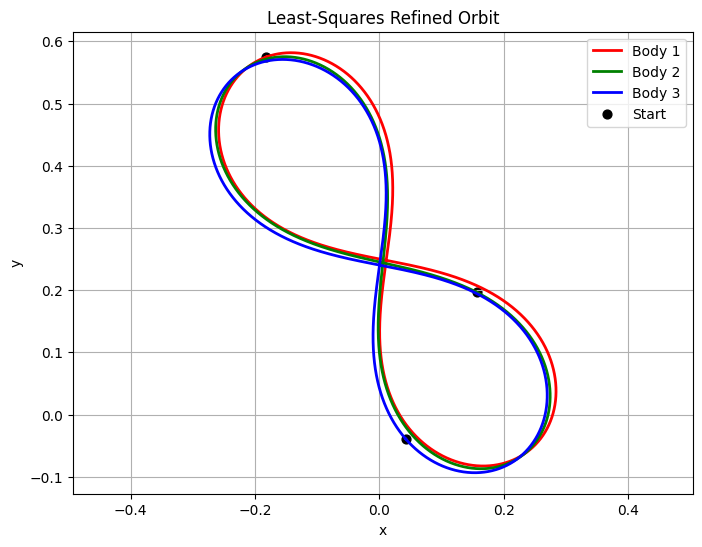

In [ ]:
y0_numeric = np.array([
    y0_refined[0],   # x1
    y0_refined[1],   # y1
    y0_refined[6],   # vx1
    y0_refined[7],   # vy1

    y0_refined[2],   # x2
    y0_refined[3],   # y2
    y0_refined[8],   # vx2
    y0_refined[9],   # vy2

    y0_refined[4],   # x3
    y0_refined[5],   # y3
    y0_refined[10],  # vx3
    y0_refined[11]   # vy3
])

sol = solve_ivp(
    three_body_numeric,
    [0, T_refined],
    y0_numeric,
    t_eval=np.linspace(0, T_refined, 5000),
    rtol=1e-10,
    atol=1e-12
)

# extract trajectories
x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Plot refined orbit
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(x1_n, y1_n, 'r-', lw=2, label='Body 1')
plt.plot(x2_n, y2_n, 'g-', lw=2, label='Body 2')
plt.plot(x3_n, y3_n, 'b-', lw=2, label='Body 3')

# starting points
plt.scatter(
    [x1_n[0], x2_n[0], x3_n[0]],
    [y1_n[0], y2_n[0], y3_n[0]],
    color='k',
    s=40,
    label='Start'
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Least-Squares Refined Orbit")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

#Compare Pinn and least squares initial conditions

In [ ]:
ic_pinn = np.array([
    x1[0], y1[0],vx1_p[0], vy1_p[0],
    x2[0], y2[0],vx2_p[0], vy2_p[0],
    x3[0], y3[0], vx3_p[0], vy3_p[0]


])


ic_refined = np.array([
    y0_refined[0],   # x1
    y0_refined[1],   # y1
    y0_refined[6],   # vx1
    y0_refined[7],   # vy1

    y0_refined[2],   # x2
    y0_refined[3],   # y2
    y0_refined[8],   # vx2
    y0_refined[9],   # vy2

    y0_refined[4],   # x3
    y0_refined[5],   # y3
    y0_refined[10],  # vx3
    y0_refined[11]   # vy3
])


# ==========================================================
# Compare PINN and Least-Squares Initial Conditions
# ==========================================================

labels = [
    "x1","y1","vx1","vy1",
    "x2","y2","vx2","vy2",
    "x3","y3","vx3","vy3"
]

delta = ic_refined - ic_pinn

print("=" * 70)
print("PINN vs Least-Squares Initial Conditions")
print("=" * 70)

print(
    f"{'Variable':<8}"
    f"{'PINN':>15}"
    f"{'LeastSq':>15}"
    f"{'Difference':>15}"
)

print("-" * 70)

for name, pinn_val, ls_val, d in zip(labels, ic_pinn, ic_refined, delta):
    print(
        f"{name:<8}"
        f"{pinn_val:>15.8f}"
        f"{ls_val:>15.8f}"
        f"{d:>15.3e}"
    )

print("-" * 70)

abs_norm = np.linalg.norm(delta)
rel_norm = abs_norm / np.linalg.norm(ic_pinn)

print(f"\nAbsolute correction norm : {abs_norm:.6e}")
print(f"Relative correction norm : {100*rel_norm:.4f}%")

print("\nInterpretation:")
if rel_norm < 0.01:
    print("PINN was extremely close to the periodic orbit.")
elif rel_norm < 0.05:
    print("PINN found a nearby periodic orbit.")
elif rel_norm < 0.20:
    print("PINN found a reasonable approximation.")
else:
    print("Least-squares performed substantial correction.")


PINN vs Least-Squares Initial Conditions
Variable           PINN        LeastSq     Difference
----------------------------------------------------------------------
x1          -0.25081393    -0.18175645      6.906e-02
y1           0.39564305     0.57501625      1.794e-01
vx1         -1.95561617    -0.76820254      1.187e+00
vy1         -0.22181128    -0.27558388     -5.377e-02
x2           0.29115950     0.15603476     -1.351e-01
y2           0.24556720     0.19672187     -4.885e-02
vx2          1.87546080     1.81404462     -6.142e-02
vy2         -0.71398249    -0.92749915     -2.135e-01
x3          -0.02369249     0.04231901      6.601e-02
y3           0.09316146    -0.03934344     -1.325e-01
vx3          0.04715146    -1.04584208     -1.093e+00
vy3          0.87287937     1.20308303      3.302e-01
----------------------------------------------------------------------

Absolute correction norm : 1.686824e+00
Relative correction norm : 56.1071%

Interpretation:
Least-squares perform